In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing

In [22]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Hooshmand\Desktop\magic04.data",header=None,engine="python")

In [23]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [24]:
import os
print(os.path.exists(r"C:\Users\Hooshmand\Desktop\magic04.data"))

True


In [25]:
df.shape

(19020, 11)

In [26]:
df.columns = ["fLength","fWidth","fSize","fConc","fConc1","fAsym","fM3Long","fM3Trans","fAlpha","fDist","class"]

In [27]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [28]:
X = df[['fLength','fWidth','fSize','fConc','fConc1','fAsym','fM3Long','fM3Trans','fAlpha','fDist']] .values  #.astype(float)
X[0:5]


array([[ 2.87967e+01,  1.60021e+01,  2.64490e+00,  3.91800e-01,
         1.98200e-01,  2.77004e+01,  2.20110e+01, -8.20270e+00,
         4.00920e+01,  8.18828e+01],
       [ 3.16036e+01,  1.17235e+01,  2.51850e+00,  5.30300e-01,
         3.77300e-01,  2.62722e+01,  2.38238e+01, -9.95740e+00,
         6.36090e+00,  2.05261e+02],
       [ 1.62052e+02,  1.36031e+02,  4.06120e+00,  3.74000e-02,
         1.87000e-02,  1.16741e+02, -6.48580e+01, -4.52160e+01,
         7.69600e+01,  2.56788e+02],
       [ 2.38172e+01,  9.57280e+00,  2.33850e+00,  6.14700e-01,
         3.92200e-01,  2.72107e+01, -6.46330e+00, -7.15130e+00,
         1.04490e+01,  1.16737e+02],
       [ 7.51362e+01,  3.09205e+01,  3.16110e+00,  3.16800e-01,
         1.83200e-01, -5.52770e+00,  2.85525e+01,  2.18393e+01,
         4.64800e+00,  3.56462e+02]])

In [29]:
df["class"] = df["class"].map({"g": 1, "h": 0})

In [30]:
y = df['class'].values
y[0:5]

array([1, 1, 1, 1, 1])

In [31]:
print(df['class'].unique())

[1 0]


In [32]:
X = preprocessing.StandardScaler().fit(X).transform(X.astype(float))
X[0:5]

array([[-0.57722602, -0.33680419, -0.38113037,  0.06275933, -0.14892271,
         0.54104236,  0.22481824, -0.40584194,  0.47681587, -1.49786555],
       [-0.51096889, -0.57002666, -0.64859479,  0.8203834 ,  1.471776  ,
         0.51691919,  0.26036419, -0.49009359, -0.81541816,  0.15312459],
       [ 2.56827756,  6.20585836,  2.61578306, -1.87588306, -1.77324106,
         2.04499208, -1.47853633, -2.18302986,  1.88922413,  0.84263513],
       [-0.69476758, -0.68725929, -1.02947766,  1.28206912,  1.60660799,
         0.53277103, -0.33351476, -0.35535913, -0.65880358, -1.03146273],
       [ 0.51662213,  0.47638377,  0.71115708, -0.34750642, -0.28465962,
        -0.0202004 ,  0.35308602,  1.03662009, -0.88103914,  2.1764266 ]])

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (15216, 10) (15216,)
Test set: (3804, 10) (3804,)


In [34]:
from sklearn.neighbors import KNeighborsClassifier

In [45]:
k = 4
#Train Model and Predict  
neigh = KNeighborsClassifier(n_neighbors = k).fit(X_train,y_train)
neigh

,n_neighbors,4
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [46]:
yhat = neigh.predict(X_test)
yhat[0:5]

array([1, 1, 1, 1, 0])

In [47]:
from sklearn import metrics
print("Train set Accuracy: ", metrics.accuracy_score(y_train, neigh.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(y_test, yhat))

Train set Accuracy:  0.8964248159831756
Test set Accuracy:  0.833596214511041


In [48]:
# The Best k
Ks = 4
mean_acc = np.zeros((Ks-1))
std_acc = np.zeros((Ks-1))

for n in range(1,Ks):
    
    #Train Model and Predict  
    neigh = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat=neigh.predict(X_test)
    mean_acc[n-1] = metrics.accuracy_score(y_test, yhat)

    
    std_acc[n-1]=np.std(yhat==y_test)/np.sqrt(yhat.shape[0])

mean_acc

array([0.81361725, 0.80126183, 0.83753943])

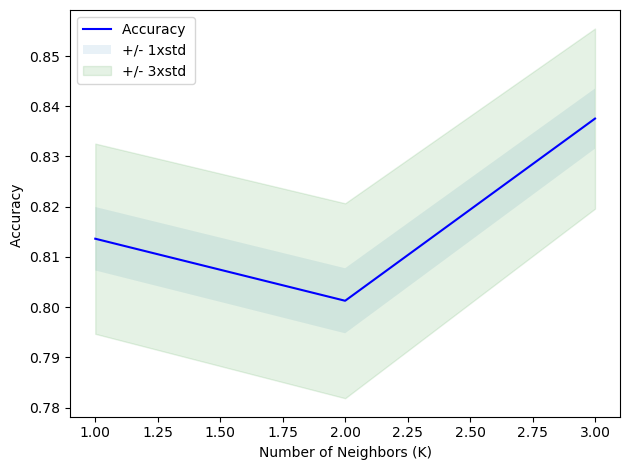

In [49]:
plt.plot(range(1,Ks),mean_acc,'b')
plt.fill_between(range(1,Ks),mean_acc - 1 * std_acc,mean_acc + 1 * std_acc, alpha=0.10)
plt.fill_between(range(1,Ks),mean_acc - 3 * std_acc,mean_acc + 3 * std_acc, alpha=0.10,color="green")
plt.legend(('Accuracy ', '+/- 1xstd','+/- 3xstd'))
plt.ylabel('Accuracy ')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()